# Signed Friedkin-Johnsen Model on a Toy Network

### 1. Import libraries

In [1]:

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Circle
import warnings

plt.rcParams.update({"figure.figsize": (7.5, 5.0), "font.size": 11, "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,})

np.set_printoptions(precision=4, suppress=True)

### 2. Input validation functions

In [2]:
#verifica che M sia una matrice quadrata 
def as_square_matrix(M, name="matrix"):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError(f"{name} must be a square matrix.")
    return M

# verifica che v sia un vettore colonna di dimensione n
def as_vector(v, n, name="vector"):
    v = np.asarray(v, dtype=float).reshape(-1)
    if v.size != n:
        raise ValueError(f"{name} must have length {n}.")
    return v

### 3. Building W function
build signed influence matrices W 
costruisce W da una lista di tuple (influenced_i, influencer_j, weight), dove i e j sono gli agenti coinvolti e weight è il peso dell'influenza
Example: (3, 1, -0.4) means W[2, 0] = -0.4, i.e. agent 1 antagonistically influences agent 3.

In [3]:
def build_W_from_edges(edges, n=6):
    W = np.zeros((n, n))
    for i, j, weight in edges:
        W[i - 1, j - 1] = weight

    #choose the diagonal so each row sums to one.
    for i in range(n):
        W[i, i] = 1.0 - np.sum(W[i, :])
    return W

### 4. SFJ Simulation 
simula la dinamica di SFJ per T iterazioni, partendo da x0 e usando W e theta

In [4]:
def simulate_sfj(W, theta, s, T):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    s = as_vector(s, n, "s")

    Theta = np.diag(theta)
    I = np.eye(n)

    A = (I - Theta) @ W
    b = Theta @ s

    X = np.zeros((n, T + 1))
    X[:, 0] = s

    for t in range(T):
        X[:, t + 1] = A @ X[:, t] + b

    return X

calcola l'equilibrio di SFJ, cioè P_W e x_star, se l'inversa esiste. P_W è la matrice che mappa x0 a x_star, e x_star è l'equilibrio raggiunto partendo da x0.

In [5]:
def compute_sfj_equilibrium(W, theta, s):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    s = as_vector(s, n, "s")

    Theta = np.diag(theta)
    I = np.eye(n)

    A = (I - Theta) @ W
    P_W = np.linalg.inv(I - A) @ Theta
    x_star = P_W @ s

    return P_W, x_star

### 5. Math diagnosis 
calcola un approssimazione del numerical range boundary

In [6]:
def numerical_range_boundary(Q, Ntheta=800):
    """Approximate the boundary of the numerical range omega(Q)."""
    Q = as_square_matrix(Q, "Q")
    angles = np.linspace(0, 2 * np.pi, int(Ntheta), endpoint=False)
    boundary = np.zeros(len(angles), dtype=complex)

    for idx, phi in enumerate(angles):
        rotated = np.exp(1j * phi) * Q
        H = (rotated + rotated.conj().T) / 2
        eigvals, eigvecs = la.eigh(H)
        v = eigvecs[:, np.argmax(eigvals)]
        boundary[idx] = np.vdot(v, Q @ v)

    return boundary

warnings about potential issues with the assumptions on theta and W, to avoid misinterpreting a simulation that violates some of the main assumptions of the paper.

In [7]:
def warn_about_assumptions(W, theta):
    """Collect the main caveats before interpreting a simulation."""
    W = as_square_matrix(W, "W")
    theta = as_vector(theta, W.shape[0], "theta")

    if np.any(theta < 0) or np.any(theta > 1):
        warnings.warn("Some theta_i are outside [0, 1]. The standard SFJ interpretation may fail.")

    if np.any(np.isclose(theta, 1.0)):
        warnings.warn(
            "Fully stubborn agents with theta_i = 1 are excluded by the main assumptions of the paper. "
            "Simulation is possible, but the theoretical guarantees used here do not apply."
        )

    if np.any(np.isclose(theta, 0.0)):
        warnings.warn(
            "Some agents have theta_i = 0. Fully non-stubborn agents require care when checking "
            "some reduced-form theoretical conditions."
        )

    row_sums = W.sum(axis=1)
    if not np.allclose(row_sums, np.ones(W.shape[0]), atol=1e-10):
        warnings.warn("Rows of W do not sum to one, so W @ 1 = 1 is not satisfied numerically.")

Check spectral properties related to stability and existence of P_W, and print them in a readable format

In [8]:
def check_sfj_stability(W, theta):
    """Print the spectral quantities I usually inspect first."""
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    Theta = np.diag(theta)
    A = (np.eye(n) - Theta) @ W

    eig_W = la.eigvals(W)
    eig_A = la.eigvals(A)
    rho_W = np.max(np.abs(eig_W))
    rho_A = np.max(np.abs(eig_A))

    print("Basic checks")
    print("------------")
    print("row sums of W:", W.sum(axis=1))
    print("W @ 1 = 1:", np.allclose(W.sum(axis=1), np.ones(n), atol=1e-10))
    print()

    print("Spectrum")
    print("--------")
    print("eig(W):", eig_W)
    print(f"rho(W) = {rho_W:.6f}")
    print("eig((I-Theta)W):", eig_A)
    print(f"rho((I-Theta)W) = {rho_A:.6f}")
    print("stable by the numerical test rho((I-Theta)W) < 1:", rho_A < 1)
    print()

    P_W, _ = compute_sfj_equilibrium(W, theta, np.zeros(n))
    if P_W is None:
        print("P_W exists numerically: False")
        print("Eigenvalues of P_W: not computable")
        print("rho(P_W): not computable")
    else:
        eig_P = la.eigvals(P_W)
        print("P_W exists numerically: True")
        print("eig(P_W):", eig_P)
        print(f"rho(P_W) = {np.max(np.abs(eig_P)):.6f}")

    print()
    print("ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.")

### 6. Metrics
opinion-level Metrics 
At the opinion level, we track the average opinion, the variance of opinions as a polarization measure, and the average absolute opinion as an extremism measure. At the stability level, we compute the spectral radius of the dynamic matrix (I - Θ)W, the corresponding stability margin, a simple convergence-time proxy, and the fraction of negative edges in the signed network.


In [9]:
# media delle opinioni
def mean_opinion(x):
    """Return the average opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    return float(np.mean(x))

#polarizzazione: varianza media delle opinioni rispetto alla media
def polarization_variance(x):
    """Return the mean squared deviation from the average opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu = np.mean(x)
    return float(np.mean((x - mu) ** 2))

#estremismo: media degli assoluti delle opinioni
def mean_extremism(x):
    """Return the average absolute opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    return float(np.mean(np.abs(x)))


def compute_opinion_metrics(x):
    """Return the three opinion-level metrics for one opinion vector."""
    return {
        "mean_opinion": mean_opinion(x),
        "polarization_variance": polarization_variance(x),
        "mean_extremism": mean_extremism(x),
    }


def compute_opinion_metrics_trajectory(X):
    """Return opinion-level metrics over a trajectory with shape (T+1, n)."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array with shape (T+1, n).")

    means = np.mean(X, axis=1)
    return {
        "mean_opinion": means,
        "polarization_variance": np.mean((X - means[:, None]) ** 2, axis=1),
        "mean_extremism": np.mean(np.abs(X), axis=1),
    }

stability-level metrics

In [10]:
#calcolo della matrice dinamica (I - Theta)W che è alla base di tutte le metriche di stabilità 
def sfj_dynamic_matrix(W, theta):
    W = np.asarray(W, dtype=float)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("W must be a square matrix.")

    theta = np.asarray(theta, dtype=float).reshape(-1)
    if theta.size != W.shape[0]:
        raise ValueError(f"theta must have length {W.shape[0]}.")

    Theta = np.diag(theta)
    return (np.eye(W.shape[0]) - Theta) @ W

#calcolo del raggio spettrale di una matrice quadrata rho < 1   → dinamica stabile/convergente, rho ≈ 1   → convergenza lenta o comportamento al limite,rho > 1   → possibile instabilità/divergenza
def spectral_radius(M):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("M must be a square matrix.")
    if M.shape[0] == 0:
        return 0.0
    return float(np.max(np.abs(np.linalg.eigvals(M))))

#calcolo del raggio spettrale di (I - Theta)W che è alla base della stabilità del modello SFJ
def sfj_spectral_radius(W, theta):
    return spectral_radius(sfj_dynamic_matrix(W, theta))

#stability margin: 1 minus the spectral radius of (I - Theta)W, misura di vicinanza all'instabilità, più è grande più siamo lontani da rho = 1, più è piccolo più siamo vicini a rho = 1
#m_rho > 0   → stabile
#m_rho = 0   → al limite
#m_rho < 0   → instabile
def stability_margin(W, theta):
    return 1.0 - sfj_spectral_radius(W, theta)

#proxy della velocità di convergenza: rho = 0.5   → convergenza veloce, rho = 0.9   → convergenza lenta, rho = 0.99  → convergenza molto lenta
#Return 1 / (1 - rho) if rho < 1, otherwise infinity. This is a common proxy for convergence time in linear systems, as the error typically decreases by a factor of rho each iteration
def convergence_time_proxy(W, theta):
    rho = sfj_spectral_radius(W, theta)
    if rho < 1:
        return 1.0 / (1.0 - rho)
    return np.inf

#misura quanto antagonistica è la rete, più è alta più la rete ha molti legami negativi rispetto a quelli totali, più è bassa più la rete ha pochi legami negativi rispetto a quelli totali
#Return the fraction of nonzero edges with negative weight.
def negative_edge_fraction(W):
    W = np.asarray(W, dtype=float)
    nonzero_edges = W != 0
    edge_count = np.count_nonzero(nonzero_edges)
    if edge_count == 0:
        return 0.0
    return float(np.count_nonzero(W < 0) / edge_count)


def compute_stability_metrics(W, theta):
    """Return the four stability-level metrics for the SFJ model."""
    rho = sfj_spectral_radius(W, theta)
    return {
        "spectral_radius": rho,
        "stability_margin": 1.0 - rho,
        "convergence_time_proxy": 1.0 / (1.0 - rho) if rho < 1 else np.inf,
        "negative_edge_fraction": negative_edge_fraction(W),
    }


### 6. Plotting functions

In [11]:
#plotta gli autovalori di W nel piano complesso, con il cerchio unitario e gli assi cartesiani per riferimento
def plot_eigenvalues(W):
    W = as_square_matrix(W, "W")
    eig_W = la.eigvals(W)

    fig, ax = plt.subplots()
    ax.add_patch(Circle((0, 0), 1, fill=False, linestyle="--", color="black", linewidth=1.2))
    ax.scatter(eig_W.real, eig_W.imag, color="red", s=55, label="eigenvalues of W", zorder=3)
    ax.axhline(0, color="0.4", linewidth=0.8)
    ax.axvline(0, color="0.4", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Eigenvalues of W")
    ax.set_xlabel("Real part")
    ax.set_ylabel("Imaginary part")
    ax.legend()
    lim = max(1.2, np.max(np.abs(np.r_[eig_W.real, eig_W.imag])) + 0.2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.show()

#plotta la rete diretta con archi rosse per influenze positive e blu per influenze negative, usando xpos e ypos per le posizioni dei nodi
def plot_signed_network(W, xpos, ypos):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    pos = {i: (xpos[i], ypos[i]) for i in range(n)}

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    positive_edges = []
    negative_edges = []

    for i in range(n):
        for j in range(n):
            if i == j or np.isclose(W[i, j], 0):
                continue
            G.add_edge(j, i)
            if W[i, j] > 0:
                positive_edges.append((j, i))
            else:
                negative_edges.append((j, i))

    fig, ax = plt.subplots()
    nx.draw_networkx_nodes(G, pos, node_color="black", node_size=520, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={i: str(i + 1) for i in range(n)}, font_color="white", ax=ax)
    nx.draw_networkx_edges(
        G, pos, edgelist=positive_edges, edge_color="red", arrows=True,
        arrowsize=18, width=[1 + 2 * abs(W[v, u]) for u, v in positive_edges],
        connectionstyle="arc3,rad=0.10", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=negative_edges, edge_color="blue", arrows=True,
        arrowsize=18, width=[1 + 2 * abs(W[v, u]) for u, v in negative_edges],
        connectionstyle="arc3,rad=-0.10", ax=ax,
    )
    ax.set_title("Signed Directed Network")
    ax.set_axis_off()
    plt.show()

#plotta la matrice W come una heatmap, con colori blu per valori negativi e rossi per valori positivi, e una barra colore che mostra la scala dei valori.
def plot_heatmap_W(W):
    W = as_square_matrix(W, "W")
    max_abs = max(1e-12, np.max(np.abs(W)))

    fig, ax = plt.subplots()
    im = ax.imshow(W, cmap="bwr", vmin=-max_abs, vmax=max_abs)
    ax.set_title("Signed Influence Matrix W")
    ax.set_xlabel("Influencing agent j")
    ax.set_ylabel("Influenced agent i")
    ax.set_xticks(range(W.shape[1]), labels=np.arange(1, W.shape[1] + 1))
    ax.set_yticks(range(W.shape[0]), labels=np.arange(1, W.shape[0] + 1))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

#plotta le traiettorie delle opinioni di tutti gli agenti nel tempo, usando marker per evidenziare i punti discreti, e una legenda che identifica ogni agente
def plot_opinion_trajectories(X, title):
    X = np.asarray(X, dtype=float)
    k_values = np.arange(X.shape[1])

    fig, ax = plt.subplots()
    for i in range(X.shape[0]):
        ax.plot(k_values, X[i, :], marker="o", markersize=3, linewidth=1.8, label=f"Agent {i + 1}")
    ax.set_title(title)
    ax.set_xlabel("Time step k")
    ax.set_ylabel("Opinion")
    ax.legend(ncol=2)
    plt.show()


#plotta il numerical range di W, con il cerchio unitario e gli autovalori di W evidenziati, per mostrare la posizione degli autovalori rispetto al numerical range e al cerchio unitario
def plot_numerical_range(W):
    W = as_square_matrix(W, "W")
    boundary = numerical_range_boundary(W)
    eig_W = la.eigvals(W)
    unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 500))

    fig, ax = plt.subplots()
    ax.fill(boundary.real, boundary.imag, color="lightsteelblue", alpha=0.65, label="numerical range")
    ax.plot(boundary.real, boundary.imag, color="royalblue", linewidth=1.4)
    ax.plot(unit_circle.real, unit_circle.imag, "k--", linewidth=1.1, label="unit circle")
    ax.scatter(eig_W.real, eig_W.imag, color="red", s=45, label="eigenvalues", zorder=3)
    ax.axhline(0, color="0.4", linewidth=0.8)
    ax.axvline(0, color="0.4", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Numerical Range of W")
    ax.set_xlabel("Real part")
    ax.set_ylabel("Imaginary part")
    ax.legend()
    plt.show()

### Network Data

In [ ]:
a12 = 0.35
a13 = 0.20
a21 = 0.35
a23 = 0.30
a31 = 0.20
a32 = 0.30
a34 = 0.10
a43 = 0.10
a45 = 0.30
a46 = 0.25
a54 = 0.35
a56 = 0.30
a64 = 0.25
a65 = 0.35

edges = [
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),
    (3, 4, a34),
    (4, 3, a43),
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),
]

#define the position of the nodes in the network
xpos = np.array([4.2, 2.7, 1.6, 2.5, 0.5, 5.8])
ypos = np.array([4.3, 4.3, 2.8, 1.5, 1.5, 2.8])

W = build_W_from_edges(edges, n=6)

#initial opinions of the agents
s = np.array([-0.30, -0.20, -0.55, 0.5, -0.6, 0.55])
#stubbornness levels of the agents
theta = np.array([0.30, 0.45, 0.35, 0.40, 0.30, 0.45])
T = 30

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

#X is the vector that stores trajectories
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [-0.2559+0.j      0.557 +0.8147j  0.557 -0.8147j  1.    +0.j
  0.8542+0.j      0.9377+0.j    ]
rho(W) = 1.000000
eig((I-Theta)W): [-0.0571+0.j      0.0481+0.0322j  0.0481-0.0322j  0.3057+0.j
  0.2209+0.j      0.1898+0.j    ]
rho((I-Theta)W) = 0.305656
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [0.729 +0.j     0.8859+0.0844j 0.8859-0.0844j 1.    +0.j
 0.9846+0.j     0.9717+0.j    ]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.


In [13]:
# This notebook stores trajectories as X.shape == (n, T + 1).
# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T

opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

print("Final opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")


Final opinion metrics:
mean_opinion: -0.0626
polarization_variance: 0.2516
mean_extremism: 0.4713

Stability metrics:
spectral_radius: 0.3057
stability_margin: 0.6943
convergence_time_proxy: 1.4402
negative_edge_fraction: 0.1667


In [14]:
print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("Equilibrium x* =", x_star)

Signed influence matrix W:
[[ 0.4   0.6   0.    0.    0.    0.  ]
 [ 0.6   0.3   0.1   0.    0.    0.  ]
 [ 0.    0.1   0.65 -0.35  0.    0.6 ]
 [ 0.    0.    0.6   0.65  0.1  -0.35]
 [ 0.    0.    0.    0.1   0.9   0.  ]
 [ 0.    0.   -0.35  0.6   0.    0.75]]

Stubbornness vector theta:
[0.74 0.8  0.95 0.95 0.79 0.55]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5  -0.6   0.55]
Equilibrium x* = [-0.2857 -0.2179 -0.5256  0.4578 -0.5726  0.7681]


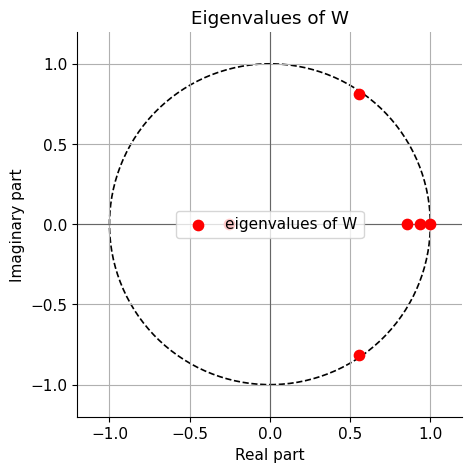

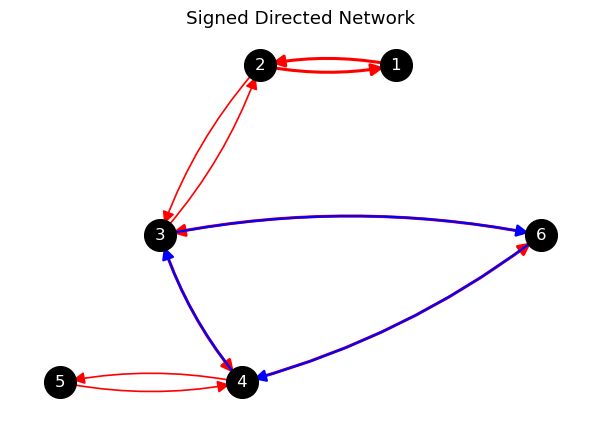

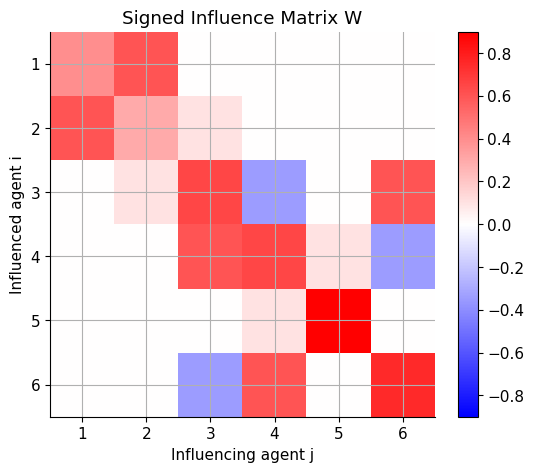

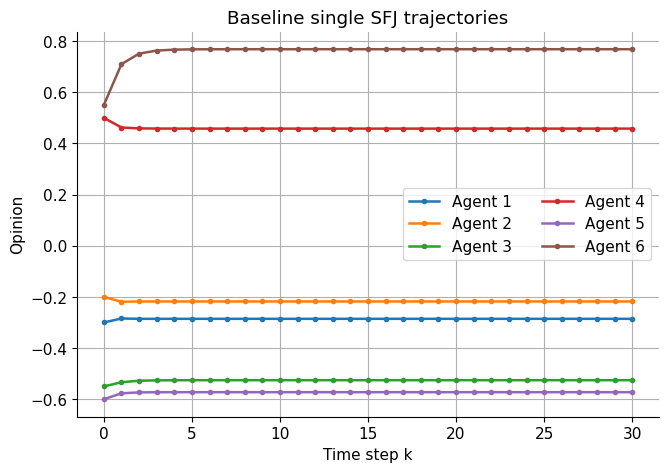

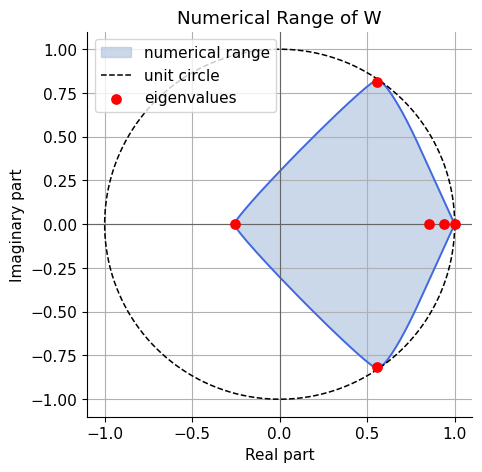

In [15]:
plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Baseline single SFJ trajectories")
plot_numerical_range(W)